# BIB - BeforeItBreacks 

A Predictive Machine learning model that predicts the failurs of machine before it happens using specific features.

Importing all required libraries for the project

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
)

sns.set_theme(style="whitegrid")

Load the data

In [7]:
df = pd.read_csv("../data/ai4i2020 (2).csv")
print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


find missing values total and duplicate total in the data set

In [8]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

checking the class balance

Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


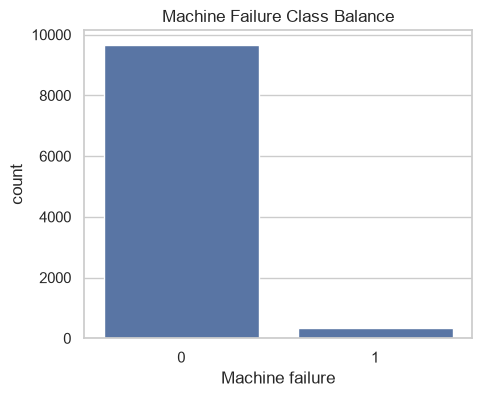

In [9]:
print(df["Machine failure"].value_counts())
print("\nFailure rate: {:.2f}%".format(df["Machine failure"].mean() * 100))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Machine failure", data=df, ax=ax)
ax.set_title("Machine Failure Class Balance")
plt.show()

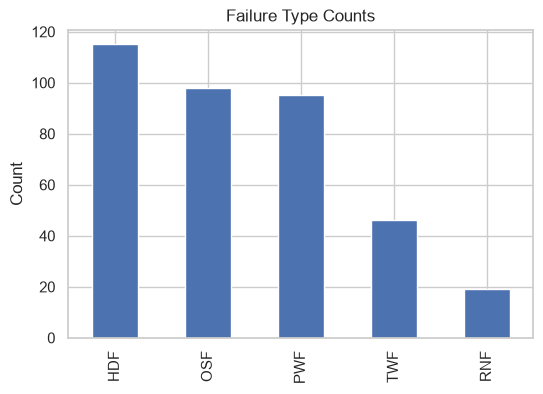

In [10]:
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]
df[failure_types].sum().sort_values(ascending=False).plot(
    kind="bar", figsize=(6, 4), title="Failure Type Counts"
)
plt.ylabel("Count")
plt.show()

feature engineering

In [11]:
df["Temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["Torque_speed_ratio"] = df["Torque [Nm]"] / df["Rotational speed [rpm]"]

df[["Temp_diff", "Torque_speed_ratio"]].describe()

,Temp_diff,Torque_speed_ratio
count,10000.000000,10000.000000
mean,10.000630,0.026895
std,1.001094,0.008838
min,7.600000,0.001317
25%,9.300000,0.020640
50%,9.800000,0.026735
75%,11.000000,0.032805
max,12.100000,0.063833


prepared fetures for the model

In [12]:
feature_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temp_diff",
    "Torque_speed_ratio",
]

# One-hot encode the product quality type (L/M/H)
type_dummies = pd.get_dummies(df["Type"], prefix="Type")

X = pd.concat([df[feature_cols], type_dummies], axis=1)
y = df["Machine failure"]

X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_diff,Torque_speed_ratio,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,10.5,0.027595,False,False,True
1,298.2,308.7,1408,46.3,3,10.5,0.032884,False,True,False
2,298.1,308.5,1498,49.4,5,10.4,0.032977,False,True,False
3,298.2,308.6,1433,39.5,7,10.4,0.027565,False,True,False
4,298.2,308.7,1408,40.0,9,10.5,0.028409,False,True,False


stratified train/test split - balancing the failures in both train & test splits in percentage

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train failure rate: {:.2f}%".format(y_train.mean() * 100))
print("Test failure rate:  {:.2f}%".format(y_test.mean() * 100))

Train failure rate: 3.39%
Test failure rate:  3.40%


balanced class weighted random forest classification - training and testing the model

In [14]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

evaluating the models accuracy and suitablility

In [15]:
print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"]))

ap = average_precision_score(y_test, y_proba)
print(f"PR-AUC (Average Precision): {ap:.3f}")

              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.80      0.78      0.79        68

    accuracy                           0.99      2000
   macro avg       0.90      0.89      0.89      2000
weighted avg       0.99      0.99      0.99      2000

PR-AUC (Average Precision): 0.816


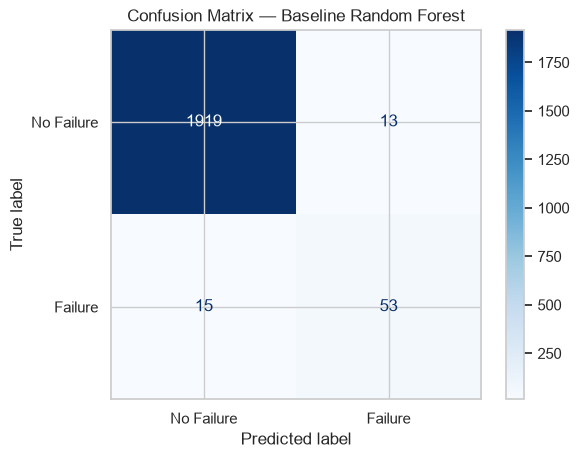

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Failure", "Failure"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Baseline Random Forest")
plt.show()

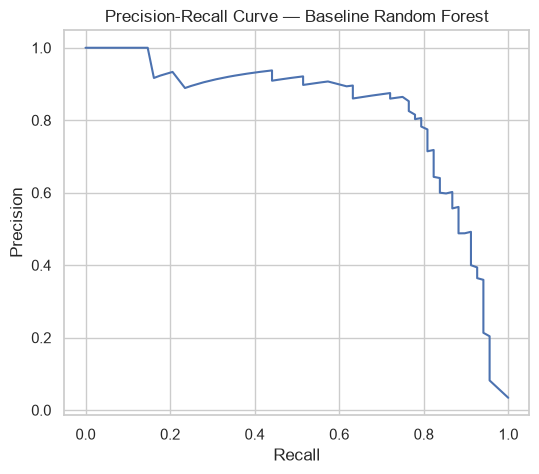

In [17]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline Random Forest")
plt.show()

feature importance

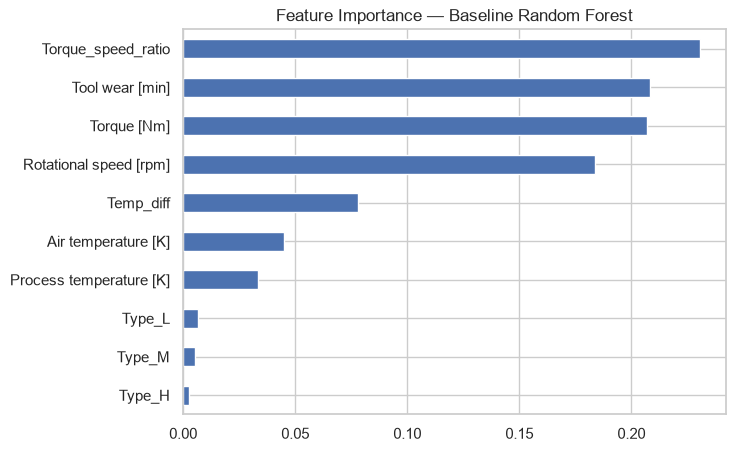

In [18]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importance — Baseline Random Forest")
plt.show()